# Trabalho C3 - Análise de Dados e Machine Learning

**Tema:** Preços de casas nos Estados Unidos  
**Dataset:** House Prices - Advanced Regression Techniques

**Grupo:** 
- Yasmim Luiz dos Santos
- Hellen Karla Costa Campos Moraes de Melo 
- José Henrique Bessi Wolkers
- Kaio Soares Pacheco  



## 1. Contexto

O objetivo do projeto é entender quais características das casas estão mais relacionadas ao preço de venda e criar modelos capazes de estimar esse valor. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, silhouette_score


try:
    from mlxtend.frequent_patterns import apriori, association_rules
except:
    !pip install mlxtend -q
    from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')


## 2. Carregamento do dataset


In [27]:
df_original = pd.read_csv('train.csv')

df = df_original.copy()

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Informações iniciais dos dados

Verificamos o tamanho do dataset, os tipos das colunas e uma descrição inicial das variáveis numéricas, a fim de entender melhor o conjunto antes de aplicar qualquer modelo.

In [28]:
print('Quantidade de linhas e colunas:', df.shape)
print('\nPrimeiras informações das colunas:')
df.info()

Quantidade de linhas e colunas: (1460, 81)

Primeiras informações das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     14

In [29]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 4. Separação entre variáveis numéricas e categóricas

Separamos as colunas numéricas e categóricas para entender melhor o dataset.

In [30]:
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas = df.select_dtypes(include=['object']).columns

print('Quantidade de variáveis numéricas:', len(colunas_numericas))
print('Quantidade de variáveis categóricas:', len(colunas_categoricas))

print('\nExemplos de colunas numéricas:')
print(list(colunas_numericas[:10]))

print('\nExemplos de colunas categóricas:')
print(list(colunas_categoricas[:10]))

Quantidade de variáveis numéricas: 38
Quantidade de variáveis categóricas: 43

Exemplos de colunas numéricas:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1']

Exemplos de colunas categóricas:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']


## 5. Valores ausentes

Verificamos quais colunas possuem valores faltantes.

In [31]:
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
faltantes

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

Colunas relacionadas a características que nem toda casa possui, como piscina, cerca, garagem ou beco, apresentam mais valores vazios. 
Vamos tratar os valores ausentes de duas formas:

- variáveis numéricas: substituí pela mediana;
- variáveis categóricas: substituí por `Sem_Info`.

## 6. Análise exploratória da variável alvo: SalePrice

A variável `SalePrice` é o preço de venda da casa. Olhamos a distribuição dos preços para entender se existem casas muito caras ou muito baratas.

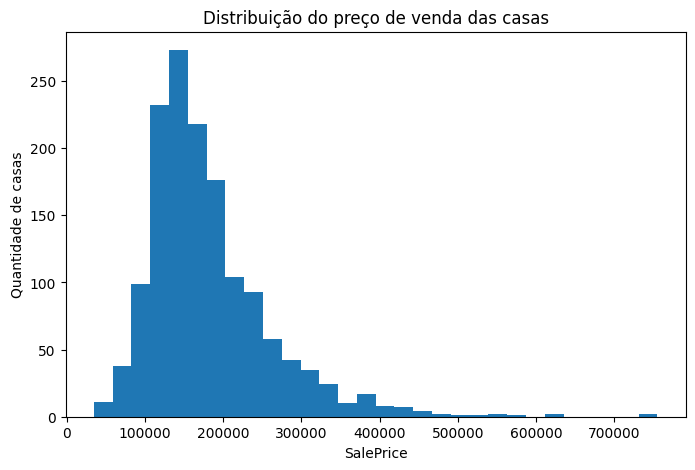

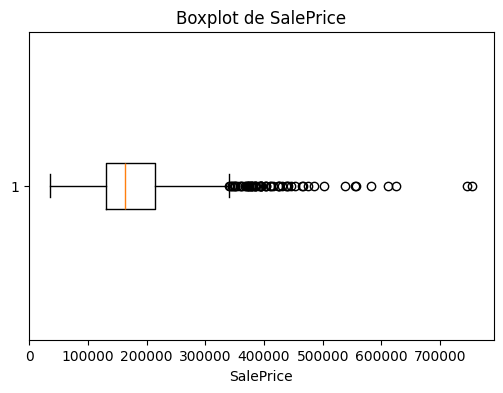

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [32]:
plt.figure(figsize=(8,5))
plt.hist(df['SalePrice'], bins=30)
plt.title('Distribuição do preço de venda das casas')
plt.xlabel('SalePrice')
plt.ylabel('Quantidade de casas')
plt.show()

plt.figure(figsize=(6, 4))
plt.boxplot(df['SalePrice'], vert=False)
plt.title('Boxplot de SalePrice')
plt.xlabel('SalePrice')
plt.show()

df['SalePrice'].describe()

Pela estatística descritiva, a base possui **1460 casas**. O preço médio de venda é de aproximadamente **180.921 dólares**, enquanto a mediana é de **163.000 dólares**. Como a média é maior que a mediana, isso indica que existem algumas casas com preços muito altos puxando a média para cima.

No histograma, a maior parte das casas está concentrada em uma faixa de preço mais baixa e intermediária, principalmente entre aproximadamente **100 mil e 250 mil dólares**. Também é possível observar uma cauda para a direita, mostrando que existem poucos imóveis com preços bem mais elevados.

O boxplot reforça essa ideia, pois apresenta vários pontos acima da faixa principal dos dados. Esses pontos indicam possíveis valores extremos, ou seja, casas com preços muito acima da maioria.


## 7. Correlação com o preço de venda

Usamos correlação para ter uma ideia inicial de quais variáveis numéricas têm mais relação com o preço da casa.

In [33]:
correlacoes = df[colunas_numericas].corr()['SalePrice'].sort_values(ascending=False)
correlacoes.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

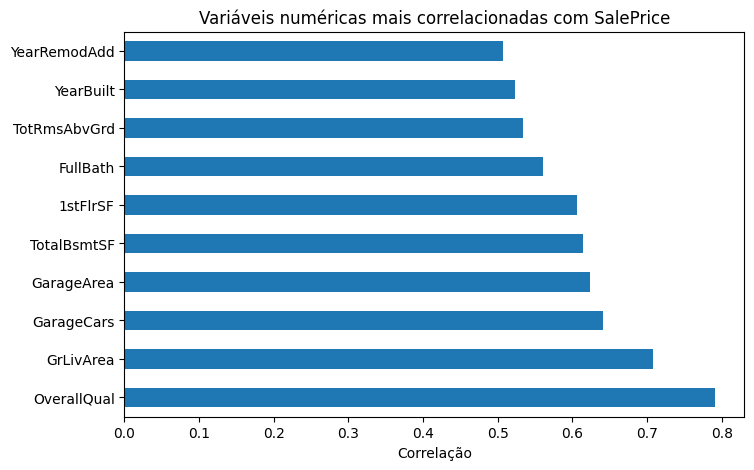

In [34]:
correlacoes.head(11).drop('SalePrice').plot(kind='barh', figsize=(8,5))
plt.title('Variáveis numéricas mais correlacionadas com SalePrice')
plt.xlabel('Correlação')
plt.show()

Pelas correlações, variáveis como qualidade geral da casa (**OverallQual**), área útil acima do solo (**GrLivArea**), tamanho da garagem (**GarageCars** e **GarageArea**) e área total do porão (**TotalBsmtSF**) aparecem entre as mais relacionadas com o preço. Isso faz sentido, porque casas maiores e com melhor qualidade tendem a ter preço maior.

## 8. Visualizações simples

Para visualizar melhor a relação entre algumas variáveis e o preço, fizemos gráficos de dispersão usando as variáveis que parecem mais importantes.

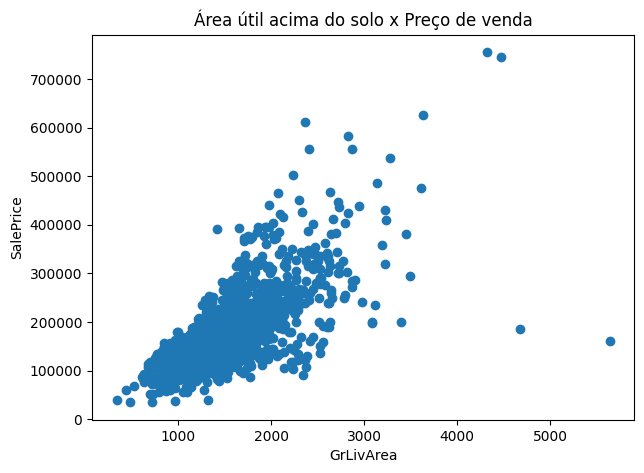

In [35]:
plt.figure(figsize=(7,5))
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.title('Área útil acima do solo x Preço de venda')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

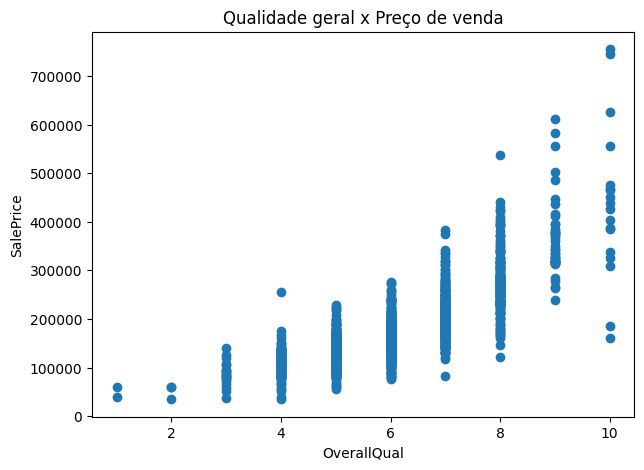

In [36]:
plt.figure(figsize=(7,5))
plt.scatter(df['OverallQual'], df['SalePrice'])
plt.title('Qualidade geral x Preço de venda')
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.show()



Nos gráficos de dispersão, é possível observar que algumas variáveis apresentam relação positiva com o preço de venda das casas.

No gráfico entre `GrLivArea` e `SalePrice`, percebe-se que, em geral, casas com maior área útil acima do solo tendem a apresentar preços de venda mais altos. Porém, também aparecem alguns pontos fora do padrão, principalmente casas com área muito grande, mas preço relativamente baixo. Esses casos podem ser considerados possíveis outliers e ajudam a justificar a análise de outliers feita posteriormente.

No gráfico entre `OverallQual` e `SalePrice`, a relação é ainda mais evidente. Conforme a qualidade geral da casa aumenta, o preço de venda também tende a aumentar. Casas com notas mais altas de qualidade aparecem concentradas em faixas de preço maiores, indicando que essa variável é uma das mais relevantes para entender o valor final do imóvel.

Assim, essas visualizações reforçam que tanto a área construída quanto a qualidade geral da casa são variáveis importantes para a análise e para os modelos de previsão de preço.

## 9. Feature Engineering

Realizamos algumas transformações simples nos dados. A ideia foi criar variáveis que podem ajudar os modelos a entender melhor as casas.

Foram criadas as seguintes variáveis:

- **Idade_Casa**: diferença entre o ano de venda e o ano de construção;
- **Idade_Reforma**: diferença entre o ano de venda e o ano da reforma;
- **Total_Banheiros**: soma aproximada dos banheiros completos e meios banheiros;
- **Area_Total**: soma de áreas importantes da casa;
- **Preco_Alto**: variável binária para classificação, onde 1 significa preço acima da mediana e 0 significa preço abaixo ou igual à mediana.

In [37]:
df['Idade_Casa'] = df['YrSold'] - df['YearBuilt']
df['Idade_Reforma'] = df['YrSold'] - df['YearRemodAdd']
df['Total_Banheiros'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])
df['Area_Total'] = df['GrLivArea'] + df['TotalBsmtSF'] + df['GarageArea']

mediana_preco = df['SalePrice'].median()
df['Preco_Alto'] = (df['SalePrice'] > mediana_preco).astype(int)

print('Mediana do preço:', mediana_preco)
df[['SalePrice', 'Idade_Casa', 'Idade_Reforma', 'Total_Banheiros', 'Area_Total', 'Preco_Alto']].head()

Mediana do preço: 163000.0


,SalePrice,Idade_Casa,Idade_Reforma,Total_Banheiros,Area_Total,Preco_Alto
0,208500,5,5,3.5,3114,1
1,181500,31,31,2.5,2984,1
2,223500,7,6,3.5,3314,1
3,140000,91,36,2.0,3115,0
4,250000,8,8,3.5,4179,1


## 10. Tratamento dos valores ausentes

Tratamos os valores faltantes. Foi feito depois de criar as novas variáveis para deixar o dataset pronto para os modelos.

In [38]:
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas = df.select_dtypes(include=['object']).columns

for coluna in colunas_numericas:
    df[coluna] = df[coluna].fillna(df[coluna].median())

for coluna in colunas_categoricas:
    df[coluna] = df[coluna].fillna('Sem_Info')

print('Total de valores ausentes depois do tratamento:', df.isnull().sum().sum())

Total de valores ausentes depois do tratamento: 0


## 11. Modelo supervisionado de regressão linear múltipla

Para prever o preço de venda da casa, usamos regressão linear múltipla. Escolhemos variáveis numéricas simples e com boa relação com o preço, além das variáveis criadas no feature engineering.

In [39]:
variaveis_regressao = [
    'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
    '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt',
    'Idade_Casa', 'Total_Banheiros', 'Area_Total'
]

X = df[variaveis_regressao]
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

modelo_regressao = LinearRegression()
modelo_regressao.fit(X_train, y_train)

previsao_regressao = modelo_regressao.predict(X_test)

mae_reg = mean_absolute_error(y_test, previsao_regressao)
rmse_reg = np.sqrt(mean_squared_error(y_test, previsao_regressao))
r2_reg = r2_score(y_test, previsao_regressao)

print('MAE:', mae_reg)
print('RMSE:', rmse_reg)
print('R²:', r2_reg)

MAE: 24682.733853570502
RMSE: 37534.45117325238
R²: 0.798106033948213


 24682.733853570404
RMSE: 37534.45117325237
R²: 0.7981060339482131


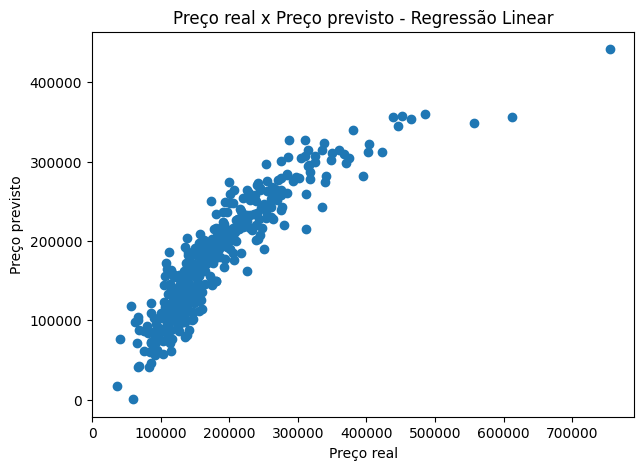

In [40]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, previsao_regressao)
plt.title('Preço real x Preço previsto - Regressão Linear')
plt.xlabel('Preço real')
plt.ylabel('Preço previsto')
plt.show()

Utilizado para prever o preço de venda das casas (`SalePrice`) a partir de algumas variáveis selecionadas do dataset.
Pelos resultados obtidos, o modelo apresentou:

- **MAE:** aproximadamente 24.683
- **RMSE:** aproximadamente 37.534
- **R²:** aproximadamente 0,798

O **MAE** indica que, em média, o modelo erra cerca de **24,6 mil dólares** nas previsões de preço. Já o **RMSE** ficou em torno de **37,5 mil dólares**, sendo um valor maior porque essa métrica penaliza mais os erros grandes.

O valor de **R² = 0,798** indica que o modelo conseguiu explicar cerca de **79,8% da variação dos preços das casas** com as variáveis utilizadas. Esse resultado pode ser considerado bom para uma primeira modelagem, principalmente por se tratar de um modelo linear simples em comparação com modelos mais complexos.

No gráfico de preço real x preço previsto, é possível observar que grande parte dos pontos segue uma tendência crescente. Isso mostra que, quando o preço real aumenta, o preço previsto pelo modelo também tende a aumentar. Porém, em casas com preços muito altos, o modelo apresenta maior dificuldade para prever corretamente, o que é comum em modelos lineares quando existem imóveis fora do padrão ou com características muito específicas.

Assim, a Regressão Linear Múltipla apresentou um desempenho satisfatório e serviu como uma boa base para prever o preço das casas, embora ainda possam existir outros fatores influenciando o valor final dos imóveis.

## 12. Modelo supervisionado de classificação com KNN

Para a parte de classificação, transformamos o preço em duas classes:

- 0: casa com preço baixo ou igual à mediana;
- 1: casa com preço alto, acima da mediana.


In [41]:
X = df[variaveis_regressao]
y = df['Preco_Alto']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Padronização
escalonador = StandardScaler()
X_train_pad = escalonador.fit_transform(X_train)
X_test_pad = escalonador.transform(X_test)

modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_pad, y_train)

previsao_knn = modelo_knn.predict(X_test_pad)

acuracia = accuracy_score(y_test, previsao_knn)
matriz = confusion_matrix(y_test, previsao_knn)

print('Acurácia:', acuracia)
print('\nMatriz de confusão:')
print(matriz)
print('\nRelatório de classificação:')
print(classification_report(y_test, previsao_knn))

Acurácia: 0.9178082191780822

Matriz de confusão:
[[212  21]
 [ 15 190]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       233
           1       0.90      0.93      0.91       205

    accuracy                           0.92       438
   macro avg       0.92      0.92      0.92       438
weighted avg       0.92      0.92      0.92       438



Utilizado para classificar as casas em duas categorias: **preço baixo** e **preço alto**. Essa divisão foi feita a partir da mediana do `SalePrice`, deixando as classes mais equilibradas para a classificação.

O modelo apresentou uma **acurácia de aproximadamente 91,78%**, ou seja, acertou a classificação da maior parte das casas do conjunto de teste.

Pela matriz de confusão, o modelo classificou corretamente:

- **212 casas** da classe 0, preço baixo;
- **190 casas** da classe 1, preço alto.

Os erros foram:

- **21 casas de preço baixo** classificadas como preço alto;
- **15 casas de preço alto** classificadas como preço baixo.

O relatório de classificação também mostra resultados equilibrados entre as duas classes. Para a classe 0, o modelo obteve **precision de 0,93**, **recall de 0,91** e **f1-score de 0,92**. Para a classe 1, obteve **precision de 0,90**, **recall de 0,93** e **f1-score de 0,91**.

Esses resultados indicam que o KNN conseguiu diferenciar bem casas de preço alto e baixo. Como as métricas ficaram próximas nas duas classes, o modelo não aparenta estar favorecendo apenas uma categoria. Assim, para este problema, o KNN apresentou um desempenho satisfatório como modelo de classificação.

## 13. Clusterização com K-Means

Na aprendizagem não supervisionada, utilizamos o K-Means para agrupar casas com características semelhantes. O algoritmo não usa o preço como alvo para aprender, ele tenta encontrar grupos com base nas variáveis escolhidas.

In [42]:
variaveis_cluster = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'Area_Total', 'Total_Banheiros']

X_cluster = df[variaveis_cluster]

escalonador_cluster = StandardScaler()
X_cluster_pad = escalonador_cluster.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_cluster_pad)

df['Cluster'] = kmeans.predict(X_cluster_pad)

print(df['Cluster'].value_counts().sort_index())

score_silhueta = silhouette_score(X_cluster_pad, df['Cluster'])
print('Score da silhueta:', score_silhueta)

Cluster
0    653
1    266
2    541
Name: count, dtype: int64
Score da silhueta: 0.2822269855393254


Score da silhueta: 0.2822269855393254


In [43]:
df.groupby('Cluster')[['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'Area_Total', 'Total_Banheiros']].mean()

,SalePrice,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,Area_Total,Total_Banheiros
Cluster,,,,,,,
0,181851.278714,6.309342,1585.581930,1.943338,1054.222052,3137.802450,2.467075
1,302282.988722,7.902256,2177.759398,2.605263,1593.729323,4498.218045,2.962406
2,120127.146026,4.959335,1105.190388,1.142329,797.611830,2220.820702,1.531423


Utilizada para separar as casas em **3 grupos**, considerando variáveis relacionadas à qualidade, tamanho, garagem, porão, área total e quantidade de banheiros.

A distribuição dos registros ficou da seguinte forma:

- **Cluster 0:** 653 casas
- **Cluster 1:** 266 casas
- **Cluster 2:** 541 casas

Ao comparar as médias dos grupos, é possível perceber diferenças claras entre os clusters.

O **Cluster 1** reúne as casas com maior preço médio, aproximadamente **302 mil dólares**. Esse grupo também apresenta as maiores médias de qualidade geral, área útil, garagem, área total, porão e banheiros. Isso indica que esse cluster representa imóveis maiores, com melhor estrutura e maior valor de venda.

O **Cluster 0** representa um grupo intermediário, com preço médio de aproximadamente **181 mil dólares**. As casas desse grupo possuem qualidade, área e quantidade de banheiros maiores que o Cluster 2, mas menores que o Cluster 1. Portanto, pode ser interpretado como um grupo de imóveis de padrão médio.

O **Cluster 2** apresenta o menor preço médio, aproximadamente **120 mil dólares**. Também possui as menores médias de qualidade geral, área útil, garagem, área total e banheiros. Assim, esse grupo representa casas menores e com características mais simples.

O **score da silhueta foi de aproximadamente 0,282**, indicando que os grupos possuem alguma separação, mas não são totalmente distintos. Isso significa que existem diferenças entre os clusters, porém algumas casas podem ter características parecidas entre mais de um grupo.

De forma geral, a clusterização conseguiu separar os imóveis em três perfis principais: casas de menor padrão, casas intermediárias e casas de maior padrão.

## 14. Redução de dimensionalidade com PCA

Foi utilizado PCA para reduzir as variáveis dos clusters para duas dimensões. Isso facilita a visualização em gráfico, mantendo parte das informações principais dos dados.

In [44]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_pad)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

print('Variância explicada pelo PCA:')
print(pca.explained_variance_ratio_)

Variância explicada pelo PCA:
[0.65889238 0.10822875]


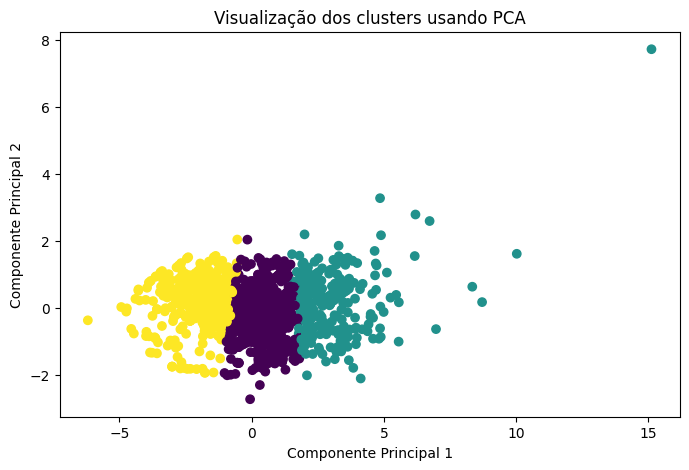

In [45]:
plt.figure(figsize=(8,5))
plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'])
plt.title('Visualização dos clusters usando PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

Aplicada para reduzir as variáveis usadas na clusterização para apenas **duas dimensões**, chamadas de **Componente Principal 1** e **Componente Principal 2**. Essa redução facilita a visualização dos grupos gerados pelo K-Means em um gráfico de dispersão.

A variância explicada pelo PCA foi de aproximadamente:

- **Componente Principal 1:** 65,9%
- **Componente Principal 2:** 10,8%

Somando os dois componentes, o gráfico representa cerca de **76,7% das informações principais** das variáveis utilizadas. Esse valor indica que a visualização em duas dimensões preserva uma parte relevante dos dados originais.

No gráfico, é possível observar que os clusters aparecem distribuídos principalmente ao longo do **Componente Principal 1**. Isso indica que a maior diferença entre os grupos está relacionada a uma combinação das variáveis de tamanho, qualidade, garagem, área total e quantidade de banheiros.

Também é possível perceber que existe alguma separação entre os grupos, mas há pontos próximos entre os clusters. Isso é coerente com o resultado da silhueta obtido na clusterização, que indicou uma separação moderada entre os grupos.

De forma geral, o PCA ajudou a visualizar melhor os agrupamentos criados pelo K-Means e mostrou que os grupos representam perfis diferentes de imóveis, mesmo que não estejam completamente separados.

## 15. Análise de associação com Apriori

Para a análise de associação, usamos algumas variáveis categóricas e também a variável `Preco_Alto`. O objetivo é procurar combinações frequentes, como por exemplo bairros, qualidade da cozinha ou condição de venda associados a preço alto ou baixo.

In [46]:
df_assoc = df[['Neighborhood', 'HouseStyle', 'KitchenQual', 'SaleCondition', 'Preco_Alto']].copy()

df_assoc['Preco_Alto'] = df_assoc['Preco_Alto'].map({0: 'Preco_Baixo', 1: 'Preco_Alto'})

transacoes = []
for i in range(len(df_assoc)):
    linha = []
    linha.append('Neighborhood=' + str(df_assoc.iloc[i]['Neighborhood']))
    linha.append('HouseStyle=' + str(df_assoc.iloc[i]['HouseStyle']))
    linha.append('KitchenQual=' + str(df_assoc.iloc[i]['KitchenQual']))
    linha.append('SaleCondition=' + str(df_assoc.iloc[i]['SaleCondition']))
    linha.append(str(df_assoc.iloc[i]['Preco_Alto']))
    transacoes.append(linha)

# Transformando as transações em colunas True/False
todos_itens = sorted(list(set([item for linha in transacoes for item in linha])))
df_transacoes = pd.DataFrame(False, index=range(len(transacoes)), columns=todos_itens)

for i in range(len(transacoes)):
    for item in transacoes[i]:
        df_transacoes.loc[i, item] = True

df_transacoes.head()

,HouseStyle=1.5Fin,HouseStyle=1.5Unf,HouseStyle=1Story,HouseStyle=2.5Fin,HouseStyle=2.5Unf,HouseStyle=2Story,HouseStyle=SFoyer,HouseStyle=SLvl,KitchenQual=Ex,KitchenQual=Fa,...,Neighborhood=Timber,Neighborhood=Veenker,Preco_Alto,Preco_Baixo,SaleCondition=Abnorml,SaleCondition=AdjLand,SaleCondition=Alloca,SaleCondition=Family,SaleCondition=Normal,SaleCondition=Partial
0,False,False,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
1,False,False,True,False,False,False,False,False,False,False,...,False,True,True,False,False,False,False,False,True,False
2,False,False,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
3,False,False,False,False,False,True,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False


In [47]:
itemsets_frequentes = apriori(df_transacoes, min_support=0.10, use_colnames=True)
itemsets_frequentes.sort_values('support', ascending=False).head(10)

,support,itemsets
9,0.820548,(SaleCondition=Normal)
4,0.503425,(KitchenQual=TA)
8,0.501370,(Preco_Baixo)
7,0.498630,(Preco_Alto)
1,0.497260,(HouseStyle=1Story)
25,0.437671,"(KitchenQual=TA, SaleCondition=Normal)"
29,0.426712,"(Preco_Baixo, SaleCondition=Normal)"
3,0.401370,(KitchenQual=Gd)
15,0.395205,"(SaleCondition=Normal, HouseStyle=1Story)"
28,0.393836,"(Preco_Alto, SaleCondition=Normal)"


In [48]:
regras = association_rules(itemsets_frequentes, metric='confidence', min_threshold=0.60)
regras = regras.sort_values(['confidence', 'lift'], ascending=False)
regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

,antecedents,consequents,support,confidence,lift
39,"(Preco_Alto, KitchenQual=TA)",(SaleCondition=Normal),0.105479,0.916667,1.117140
36,"(KitchenQual=TA, Neighborhood=NAmes)",(SaleCondition=Normal),0.108219,0.892655,1.087877
58,"(HouseStyle=2Story, KitchenQual=Gd, SaleCondit...",(Preco_Alto),0.123973,0.887255,1.779385
24,"(HouseStyle=2Story, KitchenQual=Gd)",(Preco_Alto),0.145890,0.883817,1.772491
12,(Neighborhood=NAmes),(SaleCondition=Normal),0.135616,0.880000,1.072454
10,(KitchenQual=TA),(SaleCondition=Normal),0.437671,0.869388,1.059521
45,"(Preco_Baixo, Neighborhood=NAmes)",(SaleCondition=Normal),0.106164,0.865922,1.055297
20,"(KitchenQual=TA, HouseStyle=1Story)",(SaleCondition=Normal),0.219178,0.862534,1.051168
53,"(KitchenQual=TA, Preco_Baixo, HouseStyle=1Story)",(SaleCondition=Normal),0.183562,0.856230,1.043486
22,"(Preco_Baixo, HouseStyle=1Story)",(SaleCondition=Normal),0.235616,0.855721,1.042866


Usada para identificar combinações frequentes entre algumas características das casas, como bairro, estilo, qualidade da cozinha, condição de venda e faixa de preço.

Entre os itemsets mais frequentes, aparecem **SaleCondition=Normal**, **KitchenQual=TA**, **Preco_Baixo**, **Preco_Alto** e **HouseStyle=1Story**. Isso indica que essas características aparecem bastante na base analisada.

Nas regras de associação, algumas combinações apresentaram confiança alta. Por exemplo, casas com `Preco_Alto` e `KitchenQual=TA` tiveram forte associação com **SaleCondition=Normal**. Também aparecem regras ligando **HouseStyle=2Story** e **KitchenQual=Gd** com **Preco_Alto**.

Os valores de **lift** ficaram acima de 1 em algumas regras, indicando associação positiva entre os itens. Assim, o Apriori ajudou a encontrar padrões frequentes entre características das casas, mas esses resultados devem ser vistos como relações de associação, não como causa direta do preço.

## 16. Análise de outliers com Local Outlier Factor

Usamos o Local Outlier Factor para identificar casas com comportamento diferente das demais, considerando algumas variáveis numéricas importantes.

In [49]:
variaveis_outlier = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'Area_Total']

X_outlier = df[variaveis_outlier]

escalonador_outlier = StandardScaler()
X_outlier_pad = escalonador_outlier.fit_transform(X_outlier)

lof = LocalOutlierFactor(n_neighbors=20)
outliers = lof.fit_predict(X_outlier_pad)

df['Outlier'] = outliers

print(df['Outlier'].value_counts())
print('Observação: -1 indica outlier e 1 indica não outlier.')

Outlier
 1    1327
-1     133
Name: count, dtype: int64
Observação: -1 indica outlier e 1 indica não outlier.


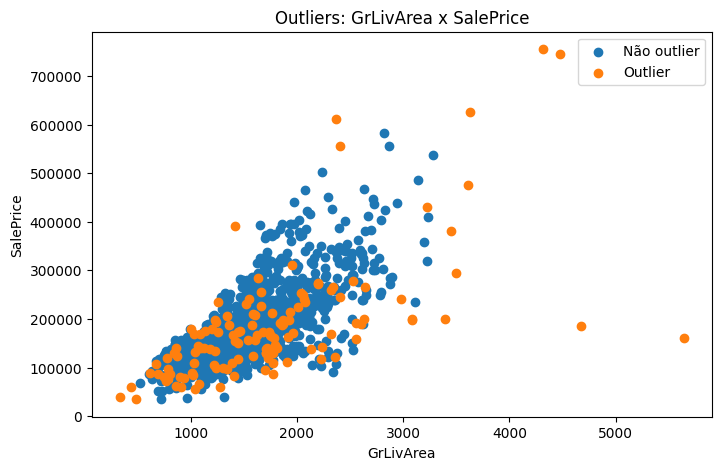

In [50]:
nao_outlier = df[df['Outlier'] == 1]
sim_outlier = df[df['Outlier'] == -1]

plt.figure(figsize=(8,5))
plt.scatter(nao_outlier['GrLivArea'], nao_outlier['SalePrice'], label='Não outlier')
plt.scatter(sim_outlier['GrLivArea'], sim_outlier['SalePrice'], label='Outlier')
plt.title('Outliers: GrLivArea x SalePrice')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.legend()
plt.show()

A análise de outliers com **Local Outlier Factor (LOF)** identificou **133 casas como possíveis outliers** e **1327 casas como não outliers**.

No gráfico entre **GrLivArea** e **SalePrice**, os outliers aparecem principalmente em pontos que fogem do padrão geral da base. Alguns exemplos são casas com área muito alta e preço relativamente baixo, ou casas com preço muito elevado em comparação com imóveis de área parecida.

Isso mostra que o LOF conseguiu destacar registros com comportamento diferente do restante dos dados. Esses casos indicam imóveis com características menos comuns, que merecem atenção em uma análise mais detalhada.

De forma geral, a técnica ajudou a identificar casas fora do padrão, complementando a análise exploratória e reforçando a importância de observar valores extremos antes da modelagem.

## 17. Comparação e interpretação das métricas

Nesta etapa, foram reunidas as principais métricas usadas para avaliar os modelos aplicados no trabalho. Como cada técnica possui um objetivo diferente, as métricas não devem ser comparadas diretamente entre si.

A Regressão Linear foi usada para prever um valor numérico, o preço da casa. A classificação com KNN foi usada para separar as casas entre preço alto e preço baixo. Já o K-Means foi usado para agrupar casas com características semelhantes, sem utilizar uma variável resposta.

In [51]:
metricas = pd.DataFrame({
    'Técnica': ['Regressão Linear', 'KNN Classificação', 'K-Means Clusterização'],
    'Tipo de problema': ['Regressão', 'Classificação', 'Não supervisionado'],
    'Objetivo': [
        'Prever o preço numérico da casa',
        'Classificar a casa como preço alto ou baixo',
        'Agrupar casas com características semelhantes'
    ],
    'Métrica principal': ['R²', 'Acurácia', 'Score da Silhueta'],
    'Valor': [r2_reg, acuracia, score_silhueta]
})

metricas


,Técnica,Tipo de problema,Objetivo,Métrica principal,Valor
0,Regressão Linear,Regressão,Prever o preço numérico da casa,R²,0.798106
1,KNN Classificação,Classificação,Classificar a casa como preço alto ou baixo,Acurácia,0.917808
2,K-Means Clusterização,Não supervisionado,Agrupar casas com características semelhantes,Score da Silhueta,0.282227


### Leitura das métricas

Na **Regressão Linear Múltipla**, o modelo apresentou **R² de aproximadamente 0,798**, indicando que conseguiu explicar cerca de 79,8% da variação dos preços. O **MAE foi de aproximadamente 24.683** e o **RMSE de aproximadamente 37.534**, mostrando que ainda existem erros nas previsões, principalmente em casas com valores mais altos ou fora do padrão.

Na **classificação com KNN**, o modelo obteve **acurácia de aproximadamente 91,8%**, indicando bom desempenho na separação entre casas de preço alto e preço baixo. A matriz de confusão mostrou que o modelo acertou bem as duas classes, sem favorecer apenas uma delas.

Na **clusterização com K-Means**, o **score da silhueta foi de aproximadamente 0,282**. Esse resultado indica uma separação moderada/fraca entre os grupos. Mesmo assim, os clusters foram úteis para identificar perfis diferentes de imóveis, como casas de menor padrão, intermediárias e de maior padrão.

De forma geral, os modelos supervisionados apresentaram resultados mais fáceis de medir, pois possuem uma variável alvo definida. Já as técnicas não supervisionadas contribuíram para explorar os dados, encontrar grupos, visualizar padrões e identificar comportamentos fora do padrão.


## 18. Conclusão

Com base nas análises realizadas, foi possível observar que o preço de venda das casas está relacionado principalmente a variáveis como **qualidade geral do imóvel (`OverallQual`)**, **área construída (`GrLivArea`)**, **tamanho da garagem**, **área do porão** e **quantidade total de banheiros**.

A **Regressão Linear Múltipla** apresentou um resultado satisfatório para uma primeira modelagem, com **R² de aproximadamente 0,798**. Isso mostra que as variáveis escolhidas explicam uma parte relevante da variação dos preços, embora o modelo ainda apresente erros em algumas previsões.

Na etapa de **classificação**, o preço foi transformado em duas categorias: preço alto e preço baixo. O modelo **KNN** obteve **acurácia de aproximadamente 91,8%**, conseguindo classificar corretamente a maior parte das casas do conjunto de teste.

Na parte de **aprendizagem não supervisionada**, o **K-Means** separou os imóveis em três grupos com perfis diferentes. O grupo com maior qualidade, maior área e mais banheiros também apresentou maior preço médio. O **PCA** ajudou a visualizar esses agrupamentos em duas dimensões.

A análise de associação com **Apriori** mostrou combinações frequentes entre características categóricas, como condição de venda, qualidade da cozinha, estilo da casa e faixa de preço. Já a análise de outliers com **Local Outlier Factor** identificou **133 registros** com comportamento diferente da maioria.
